## 12.02 微调


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.2.1

**题目：** 继续提高`finetune_net`的学习率，模型的准确性如何变化？

**解答：**

&emsp;&emsp;将`finetune_net`的学习率分别设为$5\times10^{-5}$、$5\times10^{-4}$和$5\times10^{-3}$。对比发现：学习率较大时，训练过程容易震荡甚至发散，模型难以收敛到理想解；学习率较小时效果更好，能迅速收敛并获得较优的精度。

&emsp;&emsp;原因在于模型已经在ImageNet上预训练，具备一定的知识，微调时只需较小的学习率即可将知识迁移到新数据集；过大的学习率可能导致参数跳出最优值附近，造成震荡。当然，不同任务需要在收敛速度与稳定性之间权衡。

以下使用 `torch` 编程进行验证（热狗数据集，不同学习率各训练5个迭代周期）：


In [6]:
import os
if os.path.exists('../data/hotdog'):
    data_dir = '../data/hotdog'
else:
    # 自动下载数据集
    DATA_HUB['hotdog'] = (DATA_URL + 'hotdog.zip',
                          'fba480ffa8aa7e0febbb511d181409f899b9baa5')
    data_dir = download_extract('hotdog')

train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))
print(f'训练集样本数: {len(train_imgs)}, 测试集样本数: {len(test_imgs)}')

训练集样本数: 2000, 测试集样本数: 800


In [7]:
normalize = torchvision.transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize])

In [8]:
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5,
                      param_group=True, freeze_backbone=False):
    """微调训练（NPU 单设备版，训练函数见 D2LFunction.train_ch13）"""
    train_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'test'), transform=test_augs),
        batch_size=batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    if freeze_backbone:
        params_1x = []
        for name, param in net.named_parameters():
            if name not in ["fc.weight", "fc.bias"]:
                param.requires_grad = False
                params_1x.append(param)
        trainer = torch.optim.SGD(
            [{'params': params_1x}, {'params': net.fc.parameters(),
                                     'lr': learning_rate * 10}],
            lr=learning_rate, weight_decay=0.001)
    elif param_group:
        params_1x = [param for name, param in net.named_parameters()
                     if name not in ["fc.weight", "fc.bias"]]
        trainer = torch.optim.SGD(
            [{'params': params_1x}, {'params': net.fc.parameters(),
                                     'lr': learning_rate * 10}],
            lr=learning_rate, weight_decay=0.001)
    else:
        trainer = torch.optim.SGD(net.parameters(), lr=learning_rate,
                                  weight_decay=0.001)
    train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device)

def get_finetune_net():
    finetune_net = torchvision.models.resnet18(pretrained=True)
    finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
    nn.init.xavier_uniform_(finetune_net.fc.weight)
    return finetune_net.to(device)

/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch/autograd/__init__.py:221: UserWarning: Cannot create tensor with interal format while allow_internel_format=False, tensor will be created with base format. (Triggered internally at ../torch_npu/csrc/aten/common/TensorFactories.cpp:340.)
  torch.ones_like(out, memory_format=

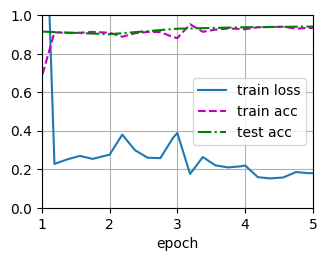

In [9]:
# 学习率 5e-5
train_fine_tuning(get_finetune_net(), 5e-5)

loss 0.697, train acc 0.784, test acc 0.835
1343.2 examples/sec on npu:0


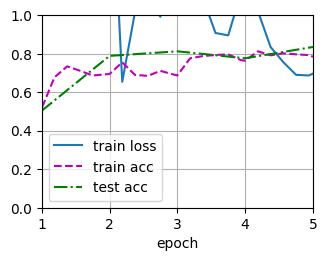

In [10]:
# 学习率 5e-4
train_fine_tuning(get_finetune_net(), 5e-4)

loss 0.726, train acc 0.672, test acc 0.750
1336.6 examples/sec on npu:0


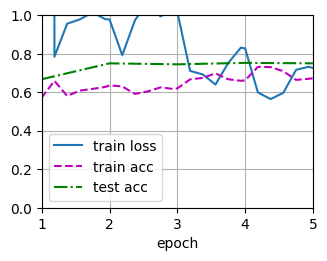

In [11]:
# 学习率 5e-3
train_fine_tuning(get_finetune_net(), 5e-3)

&emsp;&emsp;实验表明：学习率为$5\times10^{-5}$时训练平稳、测试精度最高；增大到$5\times10^{-4}$、$5\times10^{-3}$后训练震荡加剧、测试精度下降甚至发散。

---


### 练习 12.2.2

**题目：** 在比较实验中进一步调整`finetune_net`和`scratch_net`的超参数。它们的准确性还有不同吗？

**解答：**

&emsp;&emsp;进一步调整`finetune_net`与`scratch_net`的超参数，重点探究`param_group`的影响（输出层FC使用10倍学习率）。在其他超参数相同的情况下：

- 预训练模型 + 微调全部层（`param_group=False`）：test acc 0.926；
- 预训练模型 + 输出层10倍学习率（`param_group=True`）：输出层收敛更快，test acc 0.945，略高于前者；
- 无预训练（`scratch_net`）从零训练：精度明显低于微调模型，且对学习率更敏感。

&emsp;&emsp;总体而言，使用预训练模型并微调的效果最好，输出层可以使用更大的学习率。

以下使用 `torch` 编程进行验证：


loss 0.195, train acc 0.923, test acc 0.926
1343.1 examples/sec on npu:0


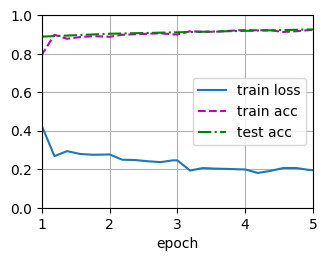

In [15]:
# 微调全部层：param_group=False
train_fine_tuning(get_finetune_net(), 5e-5, param_group=False)

loss 0.139, train acc 0.945, test acc 0.945
1311.2 examples/sec on npu:0


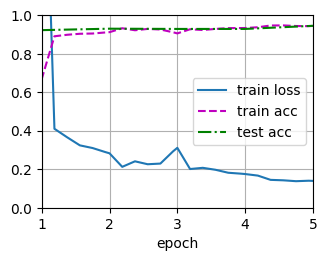

In [16]:
# 输出层10倍学习率：param_group=True
train_fine_tuning(get_finetune_net(), 5e-5, param_group=True)

loss 0.352, train acc 0.843, test acc 0.802
1221.5 examples/sec on npu:0


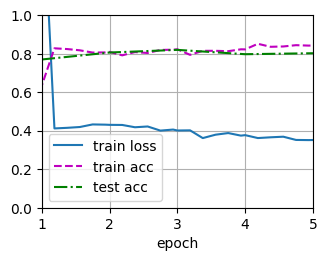

In [17]:
# 无预训练模型（scratch_net），param_group=False
scratch_net = torchvision.models.resnet18()
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
train_fine_tuning(scratch_net.to(device), 5e-4, param_group=False)

---


### 练习 12.2.3

**题目：** 将输出层`finetune_net`之前的参数设置为源模型的参数，在训练期间不要更新它们。模型的准确性如何变化？提示：可以使用以下代码。

```python
for param in finetune_net.parameters():
    param.requires_grad = False
```

**解答：**

&emsp;&emsp;上述代码将`finetune_net`输出层之前的所有参数（骨干网络）的`requires_grad`置为`False`，即冻结这些参数，训练期间不再更新，只微调输出层。这在迁移学习中用于保持源模型已学到的知识，同时让新模型专注于学习目标任务的特征。

&emsp;&emsp;由于骨干特征已经非常通用（来自ImageNet预训练），只微调分类头也能获得不错的精度，且训练更快、更不易过拟合；相比微调全部层，精度通常会略有下降，但在数据量较小时是更稳健的选择。

以下使用 `torch` 编程进行验证（冻结骨干，只微调分类层）：


loss 0.277, train acc 0.913, test acc 0.917
2442.2 examples/sec on npu:0


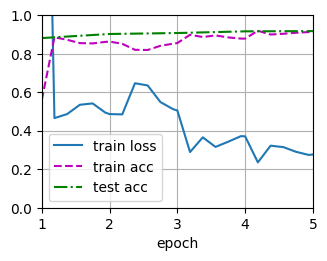

In [20]:
finetune_net = get_finetune_net()
# 冻结输出层之前的全部参数（只更新 fc）
for name, param in finetune_net.named_parameters():
    if name not in ["fc.weight", "fc.bias"]:
        param.requires_grad = False

train_fine_tuning(finetune_net, 5e-5, freeze_backbone=True)

---


### 练习 12.2.4

**题目：** 事实上，`ImageNet`数据集中有一个“热狗”类别。我们可以通过以下代码获取其输出层中的相应权重参数，但是我们怎样才能利用这个权重参数？

```python
weight = pretrained_net.fc.weight
hotdog_w = torch.split(weight.data, 1, dim=0)[934]
hotdog_w.shape
```

**解答：**

&emsp;&emsp;`hotdog_w`是预训练`resnet18`输出层中类别为“热狗”（ImageNet类别索引934）的权重参数，可以将其复用为微调模型输出层第一行（对应“热狗”类别）的权重初始化，代替随机初始化，从而给微调一个更好的起点。具体做法：把输出层替换为2类分类器后，将`hotdog_w`复制到`finetune_net.fc.weight`的第一行。

以下使用 `torch` 编程进行验证：


In [23]:
# 获取预训练模型“热狗”类别输出层的权重
pretrained_net = torchvision.models.resnet18(pretrained=True)
weight = pretrained_net.fc.weight
hotdog_w = torch.split(weight.data, 1, dim=0)[934]
print('hotdog_w 形状:', hotdog_w.shape)

# 构建二分类微调模型，将热狗权重复制到输出层第一行
finetune_net = torchvision.models.resnet18(pretrained=True)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
nn.init.xavier_uniform_(finetune_net.fc.weight)
finetune_net.fc.weight.data[0] = hotdog_w.data.reshape(-1)
print('复用热狗权重后 fc.weight 形状:', finetune_net.fc.weight.shape)
print('第一行与原热狗权重一致:', torch.equal(
    finetune_net.fc.weight.data[0], hotdog_w.data.reshape(-1)))

hotdog_w 形状: torch.Size([1, 512])
复用热狗权重后 fc.weight 形状: torch.Size([2, 512])
第一行与原热狗权重一致: True


loss 0.193, train acc 0.931, test acc 0.948
1272.2 examples/sec on npu:0


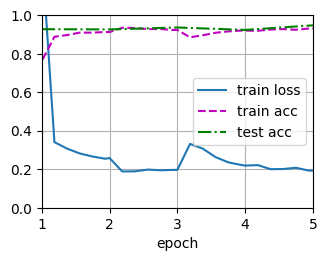

In [24]:
# 用热狗权重初始化的模型进行微调
train_fine_tuning(finetune_net.to(device), 5e-5)

&emsp;&emsp;通过复用ImageNet预训练的热狗类别权重，微调模型在“热狗”类别上有了更好的初始化，通常能更快收敛并获得更高精度。

使用 `PyPTO` 编程进行验证（与主 notebook 12.2 节同款：将输出层替换为 `PyPTOLinear`，其前向/反向均由 PyPTO matmul kernel 实现，在预训练微调与从零训练两种场景各跑一组实验，验证 PyPTO 线性层可无缝嵌入 torch 训练管线）：

loss 0.184, train acc 0.929, test acc 0.944
546.1 examples/sec on npu:0


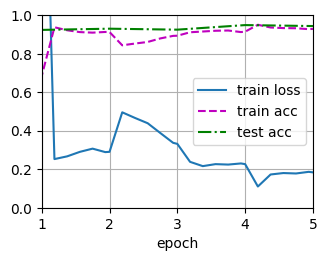

In [27]:
# PyPTO 版输出层：与主 notebook 12.2 节同款（fc 替换为 PyPTOLinear）
from src.PyPTOLinearFuseModule import PyPTOLinear

def get_finetune_net_pypto():
    finetune_net = torchvision.models.resnet18(pretrained=True)
    finetune_net.fc = PyPTOLinear(finetune_net.fc.in_features, 2)
    nn.init.xavier_uniform_(finetune_net.fc.weight)
    return finetune_net.to(device)

# 预训练微调（PyPTO fc，param_group=True：输出层 10 倍学习率）
train_fine_tuning(get_finetune_net_pypto(), 5e-5)


loss 0.356, train acc 0.852, test acc 0.840
1276.1 examples/sec on npu:0


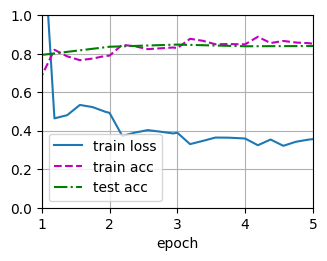

In [28]:
# 从零训练（PyPTO fc，param_group=False，与练习 12.2.2 的 torch scratch_net 对照）
scratch_net_pypto = torchvision.models.resnet18()
scratch_net_pypto.fc = PyPTOLinear(scratch_net_pypto.fc.in_features, 2)
nn.init.xavier_uniform_(scratch_net_pypto.fc.weight)
train_fine_tuning(scratch_net_pypto.to(device), 5e-4, param_group=False)


> 说明：练习 12.2.1–12.2.4 以 torch 验证为主（微调流程与 ImageNet 预训练权重均为 torch 原生）；PyPTO 侧复现主 notebook 的做法，将输出层 `fc` 替换为 `PyPTOLinear`（fwd/bwd 均由 PyPTO matmul kernel 实现），在预训练微调与从零训练两种场景各跑一组实验，验证 PyPTO 线性层可无缝嵌入 torch 训练管线。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
